In [238]:
import pandas
import matplotlib.pyplot as plt
data = pandas.read_csv('prices_round_1_day_0.csv',sep=';')
squid_ink=data[data['product']=="SQUID_INK"]

In [310]:
import pandas as pd

####################################################################################################
#
# THIS IS THE CODE FOR GETTING THE CHANGE IN VALUES (IF EACH VALUE IS A POSITIVE OR NEGATIVE VALUE)
#
####################################################################################################

data = pd.read_csv('prices_round_1_day_0.csv',sep=';')
ink = data[data['product']=="SQUID_INK"]
change1 = [] # array containing increasing price points
change2 = [] # array containing decreasing price points
change = [] # array containing all price points, if increasing = 1, if stable = 0, if decreasing = -1
diffArray = []
for i in range(1,10000,1):
    #curr = (ink.iloc[i]['ask_price_1'] + ink.iloc[i]['bid_price_1'])/2 # current mid price
    #past = (ink.iloc[i-1]['ask_price_1'] + ink.iloc[i-1]['bid_price_1'])/2 # past mid price
    grad = (ink.iloc[i]['ask_price_1']-ink.iloc[i-1]['ask_price_1'])/(ink.iloc[i]['timestamp']-ink.iloc[i-1]['timestamp']) # gradient of prices
    diff = (ink.iloc[i]['ask_price_1']-ink.iloc[i-1]['ask_price_1'])
    if grad < 0 :
        change2.append(1)
        change1.append(0)
        change.append(-1)
        diffArray.append(diff/2)
    elif grad > 0 :
        change1.append(1)
        change2.append(0)
        change.append(1)
        diffArray.append(diff/2)
    else :
        change1.append(0)
        change2.append(0)
        change.append(0)
        diffArray.append(0)

print(change)

positive=[] # A binary array with all the locations of the positive values
for j in range(len(change1)) :
    positive.append(squid_ink.iloc[j]['ask_price_1']*change1[j]+diffArray[j])
positive.append(0)
#print(positive)

negative = [] # A binary array with all the locations of the negative values
for k in range(len(change2)) :
    negative.append(squid_ink.iloc[k]['ask_price_1']*change2[k]+diffArray[k])
negative.append(0)
#print(negative)

print(diffArray)



[0, -1, -1, 0, 1, -1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, -1, 1, -1, 1, -1, 1, 0, 1, 0, 0, -1, 1, 0, 0, -1, 1, 0, -1, 0, 0, -1, 1, 0, 0, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, 1, 1, -1, -1, 1, 1, -1, 1, 0, 1, -1, 1, 0, 1, -1, 1, -1, 1, -1, 1, 1, 1, -1, -1, 0, 0, -1, 1, -1, 1, 0, 1, 1, 0, -1, 0, 1, 1, 0, 1, -1, 0, 1, 1, -1, -1, 1, 0, 0, 1, 1, -1, 1, -1, 1, -1, 1, -1, 1, 0, -1, 1, 0, 1, -1, 0, 1, -1, -1, 1, 0, -1, -1, 1, -1, 0, -1, 0, -1, 1, 1, -1, -1, 1, 1, -1, 0, 0, 0, 1, 1, 0, -1, 1, -1, 1, -1, 0, 1, 0, 1, -1, 1, -1, 0, 1, -1, -1, 0, -1, 1, -1, -1, 1, 0, 1, -1, -1, 1, 0, -1, -1, 1, 1, -1, 1, -1, 1, -1, 1, 1, 0, 1, -1, 1, -1, -1, -1, 1, 1, -1, 1, 0, 0, 1, 0, 1, -1, 1, 0, -1, 1, -1, 1, -1, 1, 1, -1, 1, 0, 0, 0, 1, 1, -1, 1, 1, -1, 1, -1, 1, 0, 1, -1, 1, 1, 0, -1, 0, 1, 0, -1, 1, 0, 0, -1, 1, 1, 0, 1, -1, 1, 0, 0, 0, -1, -1, 1, -1, -1, 1, -1, 1, 0, -1, 1, -1, 1, -1, -1, 0, 1, 1, -1, 1, -1, -1, -1, -1, 1, -1, -1, 0, -1, 1, 0, 1, 1, 0, 1, -1, 1, 0, 1, -1, -1, 1, -1, 1, -1, 0, -1, 1, -1, -1, 0, 0, -1

In [240]:
###########################################################################################
#
# THIS IS THE CODE FOR GETTING THE TREND OF THE DATA AS A WHOLE 
#
###########################################################################################

trend = []
trendNeg = []
trendPos = []

period = 5

for i in list(range(0,len(change),period)) :
    upCounter = 0
    downCounter = 0
    for j in list(range(period)) :
        if change[i+j-1] > 0 :
            upCounter = upCounter + 1
        elif change[i+j-1] < 0 :
            downCounter = downCounter + 1
    if downCounter > upCounter :
        for k in list(range(period)) :
            trend.append(-1)
            trendNeg.append(1)
            trendPos.append(0)
    elif downCounter < upCounter : 
        for k in list(range(period)) :
            trend.append(1)
            trendNeg.append(0)
            trendPos.append(1)
    else :
        for k in list(range(period)) :
            if i != 0 :
                trend.append(trend[i-1])
                trendNeg.append(trendNeg[i-1])
                trendPos.append(trendPos[i-1])
            else :
                trend.append(0)
                trendNeg.append(0)
                trendPos.append(0)

print(trend)
print(trendPos)
print(trendNeg)

[-1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, -1, -

In [308]:
###########################################################################################
#
# THIS IS THE CODE FOR GETTING THE LIVE TREND 
#
###########################################################################################
trend = []
trend.extend(change)
trendNeg = []
trendNeg.extend(change)
trendPos = []
trendPos.extend(change)
#print(trend)

period = 5

upCounter = 0
downCounter = 0
for j in range(period) :
    if change[j] > 0 :
        upCounter = upCounter + 1
    elif change[j] < 0 :
        downCounter = downCounter + 1
if downCounter > upCounter :
    for k in range(period) :
        trend[k] = -1
        trendNeg[k] = 1
        trendPos[k] = 0
elif downCounter < upCounter : 
    for k in range(period) :
        trend[k] = 1
        trendNeg[k] = 0
        trendPos[k] = 1
else :
    for k in list(range(period)) :
        trend[k] = 0
        trendNeg[k] = 0
        trendPos[k] = 0     


for i in range(period,len(change),period) :
    upCounter = 0
    downCounter = 0
    for j in range(period) :
        if change[i-j] > 0 :
            upCounter = upCounter + 1
        elif change[i-j] < 0 :
            downCounter = downCounter + 1
    if downCounter > upCounter :
        for k in range(period) :
            trend[i-k+1] = -1
            trendNeg[i-k+1] = 1
            trendPos[i-k+1] = 0
    elif downCounter < upCounter : 
        for k in range(period) :
            trend[i-k+1] = 1
            trendNeg[i-k+1] = 0
            trendPos[i-k+1] = 1
    else :
        for k in range(period) :
            if i > period-1 :
                trend[i-k+1] = trend[i-1]
                trendNeg[i-k+1] = trendNeg[i-1]
                trendPos[i-k+1] = trendPos[i-1]
            else :
                trend[i-k+1] = 0
                trendNeg[i-k+1] = 0
                trendPos[i-k+1] = 0

print(trend)
#print(trendPos)
#print(trendNeg)

[-1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, -1, -1, -1, -1, -1, 0, 0, 0, 0, 0, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 

In [309]:
###########################################################################################
#
# THIS IS THE CODE FOR GETTING THE ARROWS ON THE GRAPH
#
###########################################################################################

positiveTrend=[] # You can use this as the prices for the positive region
for j in range(len(change1)) :
    positiveTrend.append(squid_ink.iloc[j]['ask_price_1']*trendPos[j]+diffArray[j])
positiveTrend.append(0)
print(positive)

negativeTrend = [] # And htis as the prices for the negative region
for k in range(len(change2)) :
    negativeTrend.append(squid_ink.iloc[k]['ask_price_1']*trendNeg[k]+diffArray[k])
negativeTrend.append(0)
print(negative)


[np.int64(0), np.float64(-1.0), np.float64(-0.5), np.int64(0), np.float64(1969.0), np.float64(-1.0), np.float64(1969.0), np.int64(0), np.int64(0), np.int64(0), np.float64(1970.5), np.int64(0), np.int64(0), np.float64(1971.5), np.int64(0), np.float64(1973.0), np.float64(-1.0), np.float64(1973.0), np.float64(-1.0), np.float64(1973.5), np.float64(-0.5), np.float64(1974.5), np.int64(0), np.float64(1975.5), np.int64(0), np.int64(0), np.float64(-1.0), np.float64(1974.5), np.int64(0), np.int64(0), np.float64(-1.5), np.float64(1973.5), np.int64(0), np.float64(-0.5), np.int64(0), np.int64(0), np.float64(-1.0), np.float64(1972.5), np.int64(0), np.int64(0), np.float64(1974.5), np.float64(-1.0), np.float64(-0.5), np.float64(1973.5), np.float64(1974.5), np.float64(-1.0), np.float64(-0.5), np.float64(1972.5), np.float64(1974.0), np.float64(-1.0), np.float64(1973.5), np.float64(1974.5), np.float64(-0.5), np.float64(-0.5), np.float64(1974.0), np.float64(1975.5), np.float64(-1.0), np.float64(1974.5), n

In [ ]:
###########################################################################################
#
# THIS IS THE CODE FOR SAR (STOP AND REVERSE)
#
###########################################################################################

#sar = (squid_ink.iloc[0]['ask_price_1']+squid_ink.iloc[0]['bid_price_1'])/2 # SAR starts at the midprice/closing price of the previous day.
                                                                            # Change this to the last value of day 0
sar = (squid_ink.iloc[0]['ask_price_1'])
af = 0.02 # Acceleration factor (increases 0.02 everytime a new EP is found, maxes at 0.2)
ep = 0 # Extreme point (maximum value in an uptrend/minimum value in a downtrend)
epPrev = 0 # Previous extreme point (used to check if af increases or not)
sarArray = [] # Storing all sar values so it can be graphed
epArray = []
currentRegion = [] # Region of current data, changes for every point


for i in range(len(positiveTrend)-1) :
    epArray.append(ep)
    epPrev = ep
    currentRegion = []
    if trend[i] < 0 :
        if trend[i-1] > 0 :
            af = 0.02
        j = 1
        while j < i :
            if trend[i-j] != -1 :
                break
            else :
                currentRegion.append(negativeTrend[i-j])
                j = j + 1
        print(currentRegion)
        if len(currentRegion) == 0 :
            ep = epPrev
        else :
            ep = min(currentRegion)
        sar = sar - (af * (sar - ep))
        if ep > epPrev :
            if af < 0.2 :
                af = af + 0.02
            else : 
                af = 0.2
        
    elif trend[i] > 0 : 
        if trend[i-1] < 0 :
            af = 0.02
        j = 1
        while j < i :
            if trend[i-j] != 1 :
                break
            else :
                currentRegion.append(positiveTrend[i-j])
                j = j + 1
        if len(currentRegion) == 0 :
            ep = epPrev
        else :
            ep = max(currentRegion)
        sar = (sar + af * (ep - sar))
        if ep > epPrev :
            if af < 0.2 :
                af = af + 0.02
            else : 
                af = 0.2
    #print(currentRegion)
    #print(ep)
    sarArray.append(sar)

sarArray.append(0)
print(len(epArray))
epArray.append(0)
#print((sarArray))



In [ ]:
###########################################################################################
#
# THIS IS THE CODE FOR EXTREME PRICE (PEAKS AND TROUGHS)
#
###########################################################################################

ep = 0 # Extreme point (maximum value in an uptrend/minimum value in a downtrend)
epPrev = 0 # Previous extreme point (used to check if af increases or not)
epArray = []
for i in range(len(positiveTrend)-1) :
    epArray.append(ep)
    epPrev = ep
    currentRegion = []
    if trend[i] < 0 :
        j = 1
        while j < i :
            if trend[i-j] != -1 :
                break
            else :
                currentRegion.append(negativeTrend[i-j])
                j = j + 1
            if len(currentRegion) == 0 :
                ep = epPrev
            else :
                ep = min(currentRegion)

    elif trend[i] > 0 : 
        j = 1
        while j < i :
            if trend[i-j] != 1 :
                break
            else :
                currentRegion.append(positiveTrend[i-j])
                j = j + 1
            if len(currentRegion) == 0 :
                ep = epPrev
            else :
                ep = max(currentRegion)
epArray.append(0)
print((epArray))

[0, 0, 0, np.float64(1970.0), np.float64(1968.5), np.int64(1968), np.int64(1968), np.int64(1968), np.int64(1968), np.int64(1970), np.int64(1970), np.int64(1970), np.float64(1970.5), np.int64(1971), np.int64(1971), np.float64(1971.5), np.int64(1972), np.float64(1973.0), np.float64(1973.0), np.float64(1973.0), np.float64(1973.0), np.float64(1973.0), np.float64(1973.0), np.float64(1973.0), np.int64(1975), np.float64(1975.5), np.int64(1976), np.int64(1976), np.int64(1976), np.float64(1974.5), np.float64(1974.5), np.float64(1974.5), np.float64(1973.5), np.float64(1973.5), np.float64(1973.5), np.float64(1973.5), np.float64(1973.5), np.float64(1973.5), np.float64(1973.5), np.float64(1972.5), np.int64(1973), np.int64(1973), np.float64(1974.5), np.float64(1974.5), np.float64(1973.5), np.float64(1973.5), np.float64(1973.5), np.float64(1973.5), np.float64(1973.5), np.float64(1972.5), np.float64(1974.0), np.float64(1974.0), np.float64(1974.0), np.float64(1974.5), np.float64(1974.5), np.float64(197

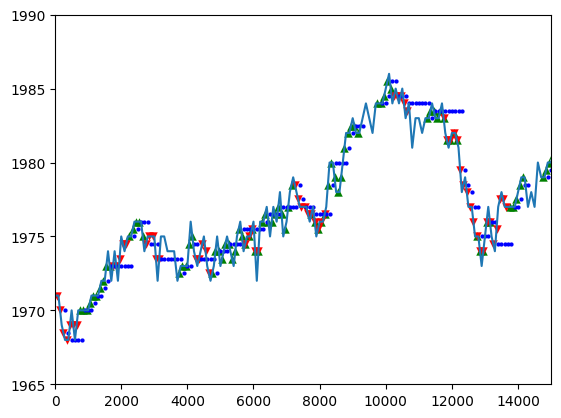

In [329]:

plt.plot(squid_ink['timestamp'],squid_ink['ask_price_1'])
plt.scatter(squid_ink['timestamp']+50,positiveTrend, color='g',marker='^',linewidths=0.05)
plt.scatter(squid_ink['timestamp']+50,negativeTrend, color='r',marker='v',linewidths=0.05)
plt.scatter(squid_ink['timestamp'],epArray, color='b',marker='.',linewidths=0.05)
ax = plt.gca()
ax.set_xlim([0, 15000])
ax.set_ylim([1965, 1990])
plt.show()